<a href="https://colab.research.google.com/github/LavanyaMaruthachalam/Acoustic-Bowel-Movements/blob/main/Acoustic_V1_Bowl_Movements.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1) Upload your files to Colab (zip or csv + wavs)

In [ ]:
!pip install umap-learn hdbscan

import os, glob
import numpy as np
import pandas as pd
import soundfile as sf
from scipy import signal, stats
from google.colab import files
import matplotlib.pyplot as plt
import librosa, librosa.display
import os, glob, zipfile
from IPython.display import Audio, display
import plotly.express as px


In [ ]:

uploaded = files.upload()  # choose your zip or csv/wavs
print("Uploaded:", list(uploaded.keys()))


Saving dataset_v2_filtered.zip to dataset_v2_filtered.zip
Uploaded: ['dataset_v2_filtered.zip']


2)Uploaded a ZIP, unzip it    3) Locate and load dataset_metadata.csv

In [ ]:
# Find the first uploaded zip
zip_files = [f for f in uploaded.keys() if f.lower().endswith(".zip")]

if zip_files:
    zip_path = zip_files[0]
    print("Unzipping:", zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall("data")
    print("Extracted to: data/")
else:
    print("No zip uploaded. If you uploaded csv/wavs directly, skip this step.")



# Search for the metadata file
candidates = glob.glob("**/dataset_metadata.csv", recursive=True)
print("Found metadata files:", candidates)

if not candidates:
    raise FileNotFoundError("dataset_metadata.csv not found. Upload it or unzip the correct folder.")

meta_path = candidates[0]
df_raw = pd.read_csv(meta_path)
print("Using:", meta_path)
print(len(df_raw))
df_raw.head(5)


Unzipping: dataset_v2_filtered.zip
Extracted to: data/
Found metadata files: ['data/dataset_metadata.csv']
Using: data/dataset_metadata.csv
7112


,filename,session_id,datetime,chunk_index,minutes_until_defecation,minutes_since_last_defecation,minutes_since_meal,minutes_since_wake,duration,original_file
0,10_28_1629_chunk_001.wav,1,2025-10-28 16:29:00,1,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav
1,10_28_1629_chunk_002.wav,1,2025-10-28 16:29:00,2,1431.0,NaN,NaN,59.0,0.20,10_28_1629.wav
2,10_28_1629_chunk_003.wav,1,2025-10-28 16:29:00,3,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav
3,10_28_1629_chunk_004.wav,1,2025-10-28 16:29:00,4,1431.0,NaN,NaN,59.0,0.17,10_28_1629.wav
4,10_28_1629_chunk_005.wav,1,2025-10-28 16:29:00,5,1431.0,NaN,NaN,59.0,0.16,10_28_1629.wav


In [ ]:
# Remove outlier session 7

print("Rows before filter:", len(df_raw))
print("Sessions:", df_raw["session_id"].nunique())

OUTLIER_SESSION_ID = 7
df = df_raw[df_raw["session_id"] != OUTLIER_SESSION_ID].copy()

print("Rows after filter:", len(df))
print("Sessions:", df["session_id"].nunique())

Rows before filter: 7112
Sessions: 11
Rows after filter: 6348
Sessions: 10


# 4) Basic metadata inspection + quick plots  and 5) Time-to-defecation vs duration (scatter)

Shape: (6348, 10)

Columns:
 ['filename', 'session_id', 'datetime', 'chunk_index', 'minutes_until_defecation', 'minutes_since_last_defecation', 'minutes_since_meal', 'minutes_since_wake', 'duration', 'original_file']

Missing values (%):
 filename                          0.00
session_id                        0.00
datetime                          0.00
chunk_index                       0.00
minutes_until_defecation          0.50
minutes_since_last_defecation    13.04
minutes_since_meal                1.01
minutes_since_wake                0.00
duration                          0.00
original_file                     0.00
dtype: float64


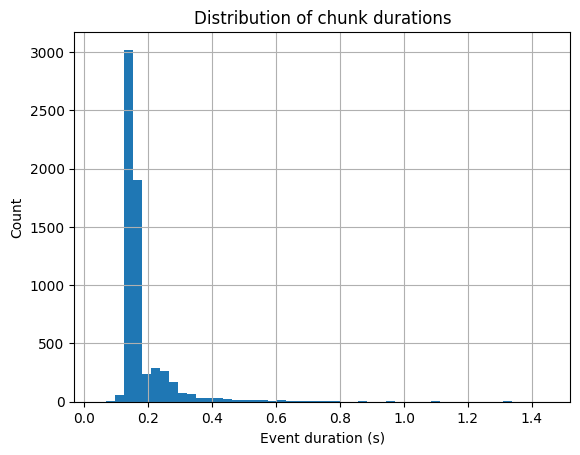

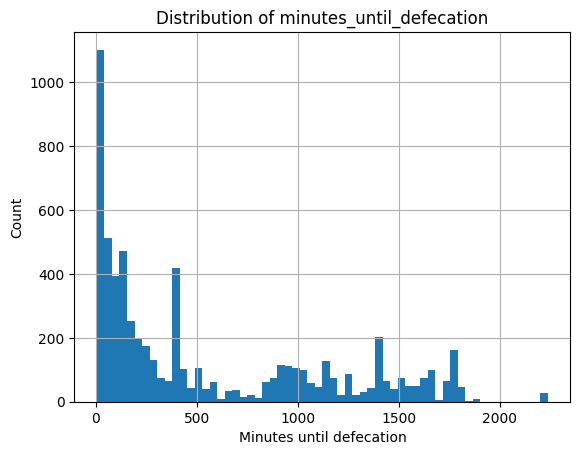

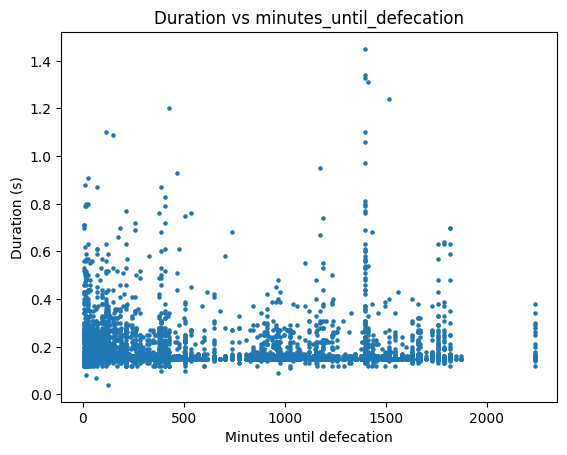

In [ ]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())
print("\nMissing values (%):\n", (df.isna().mean()*100).round(2))

# Duration distribution
plt.figure()
df["duration"].dropna().hist(bins=50)
plt.xlabel("Event duration (s)")
plt.ylabel("Count")
plt.title("Distribution of chunk durations")
plt.show()

# minutes_until_defecation distribution (ignore NaNs)
plt.figure()
df["minutes_until_defecation"].dropna().hist(bins=60)
plt.xlabel("Minutes until defecation")
plt.ylabel("Count")
plt.title("Distribution of minutes_until_defecation")
plt.show()

plt.figure()
tmp = df.dropna(subset=["minutes_until_defecation", "duration"])
plt.scatter(tmp["minutes_until_defecation"], tmp["duration"], s=5)
plt.xlabel("Minutes until defecation")
plt.ylabel("Duration (s)")
plt.title("Duration vs minutes_until_defecation")
plt.show()


Snippet A: One-time “Cycle Builder” (paste right after loading metadata)

Use this once early in the notebook (after df is loaded and datetime parsed).

In [ ]:


# Ensure datetime is datetime
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

# Keep only rows usable for "time-to-next-defecation" analyses
df = df.dropna(subset=["minutes_until_defecation"]).copy()
df["minutes_until_defecation"] = df["minutes_until_defecation"].astype(float)

# Sort correctly (important!)
df = df.sort_values(["session_id", "datetime"]).copy()

# --- Detect defecation-cycle boundaries within each session ---
df["minute_diff"] = df.groupby("session_id")["minutes_until_defecation"].diff()
df["new_cycle_flag"] = (df["minute_diff"] > 0).astype(int)
df["cycle_id"] = df.groupby("session_id")["new_cycle_flag"].cumsum()
df["global_cycle_id"] = df["session_id"].astype(str) + "_" + df["cycle_id"].astype(str)

print("Unique sessions:", df["session_id"].nunique())
print("Unique cycles (defecation anchors):", df["global_cycle_id"].nunique())
print("Cycles per session:\n", df.groupby("session_id")["global_cycle_id"].nunique().sort_index())

# Sanity: cycles should be monotonic decreasing
bad = df.groupby("global_cycle_id")["minutes_until_defecation"].apply(lambda s: (s.diff() > 0).sum())
print("Cycles with any increase (should be near 0):", (bad > 0).sum())

Unique sessions: 10
Unique cycles (defecation anchors): 22
Cycles per session:
 session_id
1     1
2     3
3     2
4     3
5     2
6     3
8     1
9     4
10    2
11    1
Name: global_cycle_id, dtype: int64
Cycles with any increase (should be near 0): 0


In [ ]:
df_raw = df.copy()  # keep original

# rows where minutes_until_defecation is NaN
t2d_nan = df_raw[df_raw["minutes_until_defecation"].isna()].copy()
print("Rows with minutes_until_defecation NaN:", len(t2d_nan))
display(t2d_nan[["filename","session_id","datetime","minutes_until_defecation"]].head(50))

print(t2d_nan["session_id"].value_counts(dropna=False))

# now drop
df = df_raw.dropna(subset=["minutes_until_defecation"]).copy()
print("After drop, df rows:", len(df))

Rows with minutes_until_defecation NaN: 0


,filename,session_id,datetime,minutes_until_defecation


Series([], Name: count, dtype: int64)
After drop, df rows: 6316


In [ ]:
nan_summary = df_raw.isna().sum()
print(nan_summary[nan_summary > 0].sort_values(ascending=False))

minutes_since_last_defecation    828
minutes_since_meal                64
minute_diff                       10
dtype: int64


In [ ]:
nan_summary = df.isna().sum()
print(nan_summary[nan_summary > 0])

minutes_since_last_defecation    828
minutes_since_meal                64
minute_diff                       10
dtype: int64


Specifically inspect minutes_until_defecation NaNs

In [ ]:
t2d_nan = df[df["minutes_until_defecation"].isna()]
print("Rows with minutes_until_defecation NaN:", len(t2d_nan))
display(t2d_nan[["filename","session_id","datetime","minutes_until_defecation"]].head(20))

Rows with minutes_until_defecation NaN: 0


,filename,session_id,datetime,minutes_until_defecation


In [ ]:
df[df["minutes_until_defecation"].isna()]["session_id"].value_counts()

,count
session_id,


6) Load and visualize a few WAV chunks (waveform + spectrogram + playback)

This will:

find the chunks/ folder

pick a few chunks nearest to defecation (small minutes) if available

plot waveform + spectrogram

Found chunks folders: ['data/chunks']
Using chunks dir: data/chunks

File: 10_30_1824_chunk_021.wav | sr=8000 | duration=0.16s | minutes_until_defecation=6.0


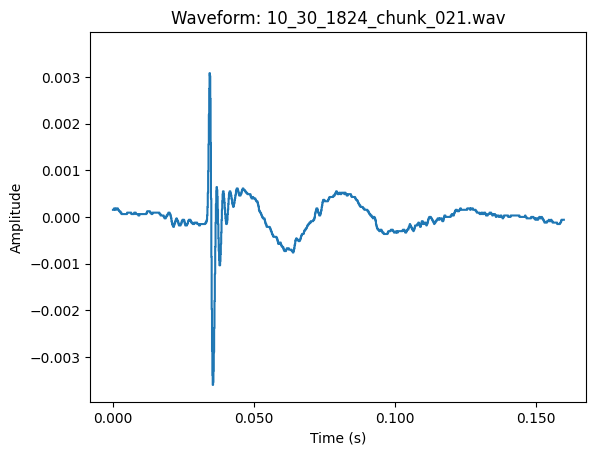

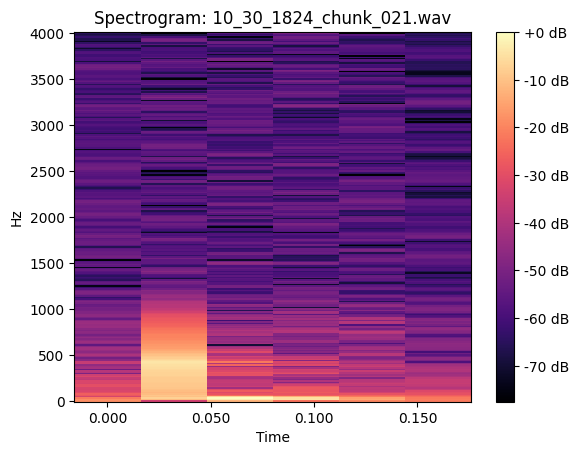


File: 10_30_1824_chunk_020.wav | sr=8000 | duration=0.24s | minutes_until_defecation=6.0


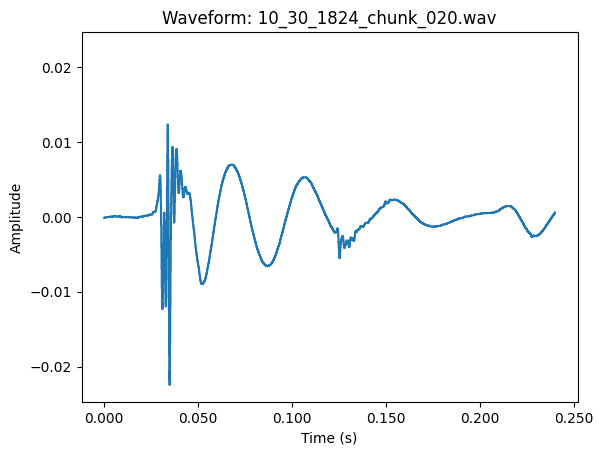

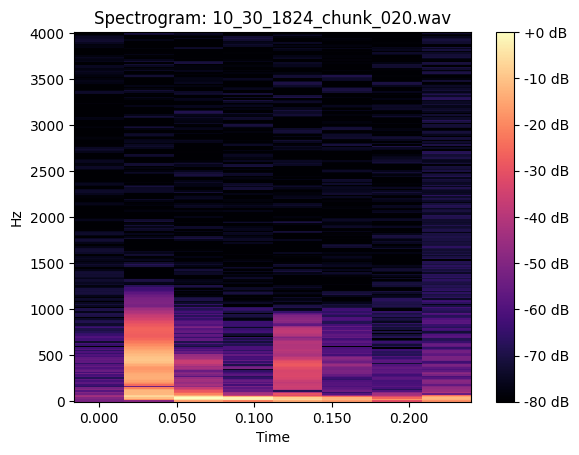


File: 10_30_1824_chunk_043.wav | sr=8000 | duration=0.24s | minutes_until_defecation=6.0


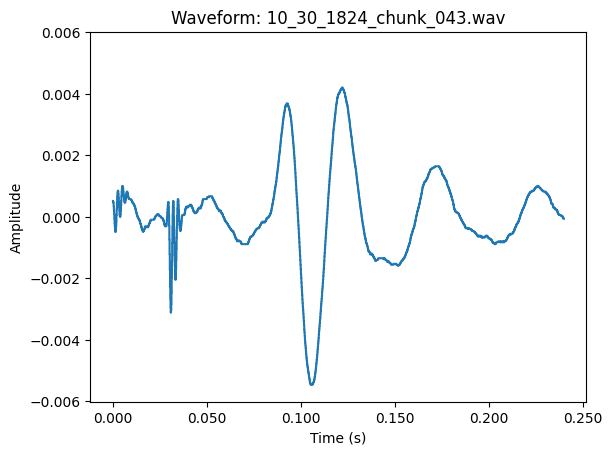

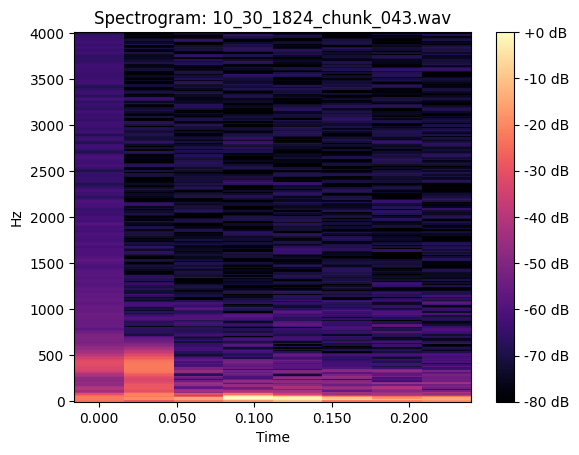


File: 10_30_1824_chunk_042.wav | sr=8000 | duration=0.43s | minutes_until_defecation=6.0


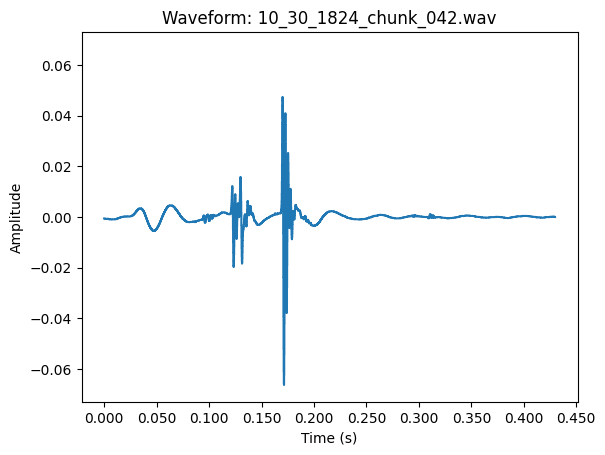

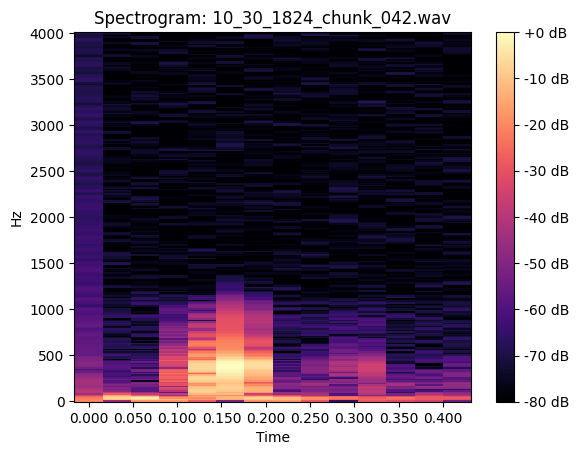


File: 10_30_1824_chunk_041.wav | sr=8000 | duration=0.39s | minutes_until_defecation=6.0


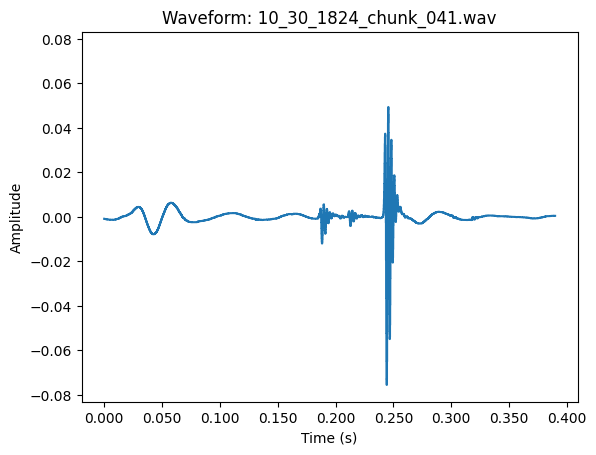

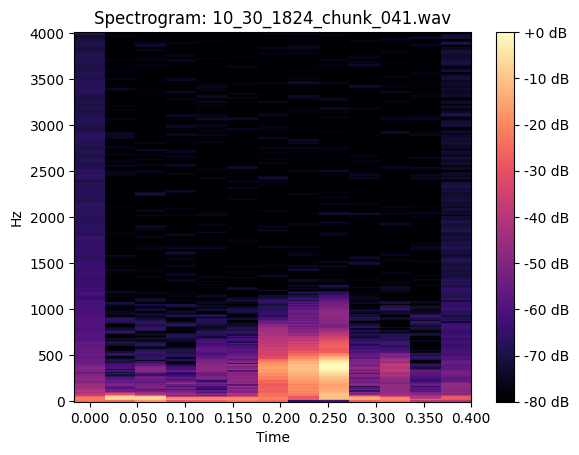

In [ ]:
# Find chunks folder
chunks_dirs = [p for p in glob.glob("**/chunks", recursive=True) if os.path.isdir(p)]
print("Found chunks folders:", chunks_dirs)

if not chunks_dirs:
    print("No chunks/ folder found. Upload wav files or unzip dataset folder containing chunks/")
else:
    chunks_dir = chunks_dirs[0]
    print("Using chunks dir:", chunks_dir)

    # Choose 5 samples: closest to defecation if label exists, else random
    if "minutes_until_defecation" in df.columns and df["minutes_until_defecation"].notna().any():
        sample_df = df.dropna(subset=["minutes_until_defecation"]).sort_values("minutes_until_defecation").head(5)
    else:
        sample_df = df.sample(10, random_state=42)

    for i, row in sample_df.iterrows():
        wav_path = os.path.join(chunks_dir, row["filename"])
        if not os.path.exists(wav_path):
            print("Missing wav:", wav_path)
            continue

        y, sr = librosa.load(wav_path, sr=None, mono=True)

        print(f"\nFile: {row['filename']} | sr={sr} | duration={len(y)/sr:.2f}s | minutes_until_defecation={row.get('minutes_until_defecation', None)}")

        # Waveform
        plt.figure()
        librosa.display.waveshow(y, sr=sr)
        plt.title(f"Waveform: {row['filename']}")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.show()

        # Spectrogram (dB)
        S = np.abs(librosa.stft(y, n_fft=512, hop_length=256))
        S_db = librosa.amplitude_to_db(S, ref=np.max)

        plt.figure()
        librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis="time", y_axis="hz")
        plt.colorbar(format="%+2.0f dB")
        plt.title(f"Spectrogram: {row['filename']}")
        plt.show()

        # Playback
        display(Audio(y, rate=sr))




In [ ]:
DATASET_ROOT = "data"
META_PATH = os.path.join(DATASET_ROOT, "dataset_metadata.csv")
CHUNKS_DIR = os.path.join(DATASET_ROOT, "chunks")

print("META exists:", os.path.exists(META_PATH))
print("CHUNKS dir exists:", os.path.exists(CHUNKS_DIR))


META exists: True
CHUNKS dir exists: True


In [ ]:

print("Rows:", len(df))
print("Columns:", df.columns.tolist())
df.head()


Rows: 6316
Columns: ['filename', 'session_id', 'datetime', 'chunk_index', 'minutes_until_defecation', 'minutes_since_last_defecation', 'minutes_since_meal', 'minutes_since_wake', 'duration', 'original_file', 'minute_diff', 'new_cycle_flag', 'cycle_id', 'global_cycle_id']


,filename,session_id,datetime,chunk_index,minutes_until_defecation,minutes_since_last_defecation,minutes_since_meal,minutes_since_wake,duration,original_file,minute_diff,new_cycle_flag,cycle_id,global_cycle_id
0,10_28_1629_chunk_001.wav,1,2025-10-28 16:29:00,1,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav,NaN,0,0,1_0
1,10_28_1629_chunk_002.wav,1,2025-10-28 16:29:00,2,1431.0,NaN,NaN,59.0,0.20,10_28_1629.wav,0.0,0,0,1_0
2,10_28_1629_chunk_003.wav,1,2025-10-28 16:29:00,3,1431.0,NaN,NaN,59.0,0.15,10_28_1629.wav,0.0,0,0,1_0
3,10_28_1629_chunk_004.wav,1,2025-10-28 16:29:00,4,1431.0,NaN,NaN,59.0,0.17,10_28_1629.wav,0.0,0,0,1_0
4,10_28_1629_chunk_005.wav,1,2025-10-28 16:29:00,5,1431.0,NaN,NaN,59.0,0.16,10_28_1629.wav,0.0,0,0,1_0


Step 2: Keep events with valid minutes_until_defecation


In [ ]:
df2 = df[df["minutes_until_defecation"].notna()].copy()
df2["minutes_until_defecation"] = df2["minutes_until_defecation"].astype(float)

print("Events with target:", len(df2))
print("Target range (min):", df2["minutes_until_defecation"].min(), "to", df2["minutes_until_defecation"].max())
df2[["filename", "session_id", "datetime", "minutes_until_defecation", "duration"]].head()


Events with target: 6316
Target range (min): 6.0 to 2238.0


,filename,session_id,datetime,minutes_until_defecation,duration
0,10_28_1629_chunk_001.wav,1,2025-10-28 16:29:00,1431.0,0.15
1,10_28_1629_chunk_002.wav,1,2025-10-28 16:29:00,1431.0,0.20
2,10_28_1629_chunk_003.wav,1,2025-10-28 16:29:00,1431.0,0.15
3,10_28_1629_chunk_004.wav,1,2025-10-28 16:29:00,1431.0,0.17
4,10_28_1629_chunk_005.wav,1,2025-10-28 16:29:00,1431.0,0.16


# CODE SET :4


In [ ]:
# ============================================================
# CODE SET 4 (Merged) - UPDATED to CYCLE-AWARE
# ============================================================

# -------------------------
# 1) Paths + Output
OUT_DIR = "results_code_set4"
os.makedirs(OUT_DIR, exist_ok=True)

print("META exists:", os.path.exists(META_PATH))
print("CHUNKS dir exists:", os.path.exists(CHUNKS_DIR))

# -------------------------
# 2) Global Parameters
# -------------------------
OUTLIER_SESSION_ID = 7
DROP_OUTLIER_SESSION = True

SESSIONS_TO_REMOVE = [1, 8, 9]

HP_CUTOFF_HZ = 20
HP_ORDER = 2

STFT_WINDOW = "hann"
STFT_BASE_NFFT_16K = 1024
STFT_BASE_NFFT_8K = 512
MIN_SPECTRAL_NPERSEG = 32

bins = [0, 30, 60, 120, 240, 360, 480, 720, 1440, 999999]
labels_near_to_far = ["0-30m","30-60m","1-2h","2-4h","4-6h","6-8h","8-12h","12-24h",">24h"]
order_far_to_near = [">24h","12-24h","8-12h","6-8h","4-6h","2-4h","1-2h","30-60m","0-30m"]

BASELINE_MIN = 480
MIN_BASELINE_N = 10

NEAR_MAX = 60
FAR_MIN = 480

Z_FEATURES = ["feat_centroid_mean", "feat_flatness_mean", "feat_duration_s", "feat_env_mean", "feat_zcr"]

# -------------------------
# 3) Utility Functions
# -------------------------
def teager_kaiser_energy(x):
    x = np.asarray(x)
    if len(x) < 3:
        return np.array([0.0])
    return x[1:-1]**2 - x[:-2] * x[2:]

def highpass(x, sr, cutoff_hz=HP_CUTOFF_HZ, order=HP_ORDER):
    if len(x) < 64 or sr < 100:
        return x
    b, a = signal.butter(order, cutoff_hz / (sr / 2), btype="highpass")
    return signal.filtfilt(b, a, x)

def add_bins(df_):
    df_ = df_.copy()
    df_["t2d_bin"] = pd.cut(
        df_["minutes_until_defecation"],
        bins=bins,
        labels=labels_near_to_far,
        include_lowest=True
    )
    df_["t2d_bin"] = pd.Categorical(df_["t2d_bin"],
                                    categories=order_far_to_near,
                                    ordered=True)
    return df_

def rank_biserial_from_U(U, n1, n2):
    return 1 - (2 * U) / (n1 * n2)

def cliffs_delta(a, b):
    a = np.asarray(a); b = np.asarray(b)
    a = a[~np.isnan(a)]; b = b[~np.isnan(b)]
    if len(a) == 0 or len(b) == 0:
        return np.nan
    gt = 0
    lt = 0
    for x in a:
        gt += np.sum(x > b)
        lt += np.sum(x < b)
    return (gt - lt) / (len(a) * len(b))

def bootstrap_ci_median(x, n_boot=800, ci=95, seed=42):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    if len(x) < 5:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    meds = []
    for _ in range(n_boot):
        samp = rng.choice(x, size=len(x), replace=True)
        meds.append(np.median(samp))
    lo = np.percentile(meds, (100-ci)/2)
    hi = np.percentile(meds, 100-(100-ci)/2)
    return np.median(x), lo, hi

def _rolloff95(f, M):
    cumsum = np.cumsum(M, axis=0)
    total = cumsum[-1, :] + 1e-12
    T = cumsum.shape[1]
    roll = np.zeros(T, dtype=np.float32)
    for i in range(T):
        idx = np.searchsorted(cumsum[:, i], 0.95 * total[i])
        idx = min(idx, len(f) - 1)
        roll[i] = f[idx]
    return roll

# -------------------------
# 4) Hybrid Feature Extraction
# -------------------------
def extract_features_hybrid(wav_path):
    x, sr = sf.read(wav_path)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(np.float32)

    x = highpass(x, sr, cutoff_hz=HP_CUTOFF_HZ, order=HP_ORDER)

    dur = len(x) / sr
    rms = float(np.sqrt(np.mean(x**2) + 1e-12))
    peak = float(np.max(np.abs(x)) + 1e-12)
    zcr = float(np.mean(np.abs(np.diff(np.sign(x))) > 0))
    peak_to_rms = float(peak / (rms + 1e-12))

    env = np.abs(signal.hilbert(x)) + 1e-12
    env_mean = float(np.mean(env))
    env_std = float(np.std(env))
    env_max = float(np.max(env))
    env_crest = float(env_max / (env_mean + 1e-12))

    base_n_fft = STFT_BASE_NFFT_16K if sr >= 16000 else STFT_BASE_NFFT_8K
    nperseg = min(base_n_fft, len(x))

    if nperseg < MIN_SPECTRAL_NPERSEG:
        centroid = np.array([0.0])
        flatness = np.array([0.0])
        roll95_amp = np.array([0.0])
        roll95_pow = np.array([0.0])
        flux_mean = 0.0
    else:
        hop = max(1, nperseg // 4)
        noverlap = min(nperseg - 1, nperseg - hop)

        f, t, Z = signal.stft(
            x,
            fs=sr,
            nperseg=nperseg,
            noverlap=noverlap,
            window=STFT_WINDOW,
            padded=False,
            boundary=None
        )
        mag = np.abs(Z) + 1e-12
        pow_ = mag**2

        centroid = (f[:, None] * mag).sum(axis=0) / mag.sum(axis=0)
        flatness = np.exp(np.mean(np.log(mag), axis=0)) / (np.mean(mag, axis=0) + 1e-12)

        roll95_amp = _rolloff95(f, mag)
        roll95_pow = _rolloff95(f, pow_)

        flux = np.sqrt(np.sum(np.diff(mag, axis=1)**2, axis=0))
        flux_mean = float(np.mean(flux)) if flux.size else 0.0

    tkeo = np.abs(teager_kaiser_energy(x))
    tkeo_mean = float(np.mean(tkeo)) if tkeo.size else 0.0
    tkeo_max = float(np.max(tkeo)) if tkeo.size else 0.0

    return {
        "sr": int(sr),
        "feat_duration_s": float(dur),
        "feat_rms": rms,
        "feat_log_rms": float(np.log(rms + 1e-12)),
        "feat_peak_to_rms": peak_to_rms,
        "feat_zcr": zcr,
        "feat_env_mean": env_mean,
        "feat_env_std": env_std,
        "feat_env_crest": env_crest,
        "feat_centroid_mean": float(np.mean(centroid)),
        "feat_centroid_std": float(np.std(centroid)),
        "feat_flatness_mean": float(np.mean(flatness)),
        "feat_roll95_amp_mean": float(np.mean(roll95_amp)),
        "feat_roll95_pow_mean": float(np.mean(roll95_pow)),
        "feat_flux_mean": flux_mean,
        "feat_tkeo_mean": tkeo_mean,
        "feat_tkeo_max": tkeo_max,
        "stft_nperseg": int(nperseg),
        "stft_hop": int(max(1, nperseg // 4)) if nperseg >= MIN_SPECTRAL_NPERSEG else 0,
        "stft_window": STFT_WINDOW,
        "hp_cutoff_hz": HP_CUTOFF_HZ,
        "hp_order": HP_ORDER,
    }

# -------------------------
# 5) Load metadata safely + Filtering
# -------------------------
df_raw = pd.read_csv(META_PATH)
print("Rows raw:", len(df_raw), "Sessions raw:", df_raw["session_id"].nunique())

df = df_raw.copy()

# Parse datetime EARLY (important for correct cycle detection)
df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

# Remove outlier session 7
if DROP_OUTLIER_SESSION and OUTLIER_SESSION_ID is not None:
    df = df[df["session_id"] != OUTLIER_SESSION_ID].copy()
    print("Removed session:", OUTLIER_SESSION_ID)

if DROP_OUTLIER_SESSION and OUTLIER_SESSION_ID is not None:
    assert OUTLIER_SESSION_ID not in df["session_id"].unique(), "Session 7 leaked back into df!"

print("Rows after removing 7:", len(df), "Sessions:", df["session_id"].nunique())

# Remove sessions 1, 8, 9 and store separately
df_removed_1_8_9 = df[df["session_id"].isin(SESSIONS_TO_REMOVE)].copy()
df_clean = df[~df["session_id"].isin(SESSIONS_TO_REMOVE)].copy()

print("\nRemoved sessions stored separately:", sorted(df_removed_1_8_9["session_id"].unique()))
print("Rows in removed set:", len(df_removed_1_8_9))

print("\nRows after removing 1,8,9:", len(df_clean))
print("Sessions after:", sorted(df_clean["session_id"].unique()))

df = df_clean

# Keep valid target
df = df.dropna(subset=["minutes_until_defecation"]).copy()
df["minutes_until_defecation"] = df["minutes_until_defecation"].astype(float)

# Sort (required for cycle boundaries)
df = df.sort_values(["session_id", "datetime"]).copy()
print("\nRows with valid minutes_until_defecation:", len(df))

# -------------------------
# 5.5) NEW: Build defecation cycles inside sessions
# -------------------------
df["minute_diff"] = df.groupby("session_id")["minutes_until_defecation"].diff()
df["new_cycle_flag"] = (df["minute_diff"] > 0).astype(int)
df["cycle_id"] = df.groupby("session_id")["new_cycle_flag"].cumsum()
df["global_cycle_id"] = df["session_id"].astype(str) + "_" + df["cycle_id"].astype(str)

print("\nUnique sessions:", df["session_id"].nunique())
print("Unique defecation cycles (anchors):", df["global_cycle_id"].nunique())
print("\nCycles per session:\n", df.groupby("session_id")["global_cycle_id"].nunique().sort_index())

# -------------------------
# 6) Extract features for ALL events (global dataset)
# -------------------------
feature_rows = []
missing = 0

for _, row in df.iterrows():
    wav_path = os.path.join(CHUNKS_DIR, row["filename"])
    if not os.path.exists(wav_path):
        missing += 1
        continue
    feats = extract_features_hybrid(wav_path)
    feats["filename"] = row["filename"]
    feature_rows.append(feats)

feat_df = pd.DataFrame(feature_rows)
print("Extracted feature rows:", len(feat_df), "Missing wavs:", missing)

data = df.merge(feat_df, on="filename", how="inner")
print("Merged rows:", len(data))

global_csv = os.path.join(OUT_DIR, "bowel_event_features_codeset4.csv")
data.to_csv(global_csv, index=False)
print("Saved global features:", global_csv)

# -------------------------
# 7) Global Binning (far -> near)
# -------------------------
data = add_bins(data)
bin_counts = data["t2d_bin"].value_counts().sort_index()
print("\nBin counts (far -> near):")
print(bin_counts)

# -------------------------
# 8) CYCLE-NORMALIZATION (z-scores)  <<<<< CHANGED HERE
# -------------------------
data_norm = data.copy()
for f in Z_FEATURES:
    data_norm[f + "_z"] = np.nan
data_norm["baseline_n"] = 0

def cycle_zscore(df_cycle):
    df_cycle = df_cycle.copy()
    base = df_cycle[df_cycle["minutes_until_defecation"] >= BASELINE_MIN]
    df_cycle["baseline_n"] = len(base)

    if len(base) < MIN_BASELINE_N:
        return df_cycle

    mu = base[Z_FEATURES].mean()
    sd = base[Z_FEATURES].std(ddof=0).replace(0, np.nan)

    for f in Z_FEATURES:
        df_cycle[f + "_z"] = (df_cycle[f] - mu[f]) / sd[f]
    return df_cycle

# IMPORTANT: group by global_cycle_id now
data_norm = data_norm.groupby("global_cycle_id", group_keys=False).apply(cycle_zscore)
data_norm = add_bins(data_norm)

norm_csv = os.path.join(OUT_DIR, "bowel_event_features_codeset4_norm.csv")
data_norm.to_csv(norm_csv, index=False)
print("Saved normalized features:", norm_csv)

# -------------------------
# 9) Global Stats Table (same global, but now data has cycles)
# -------------------------
feature_cols = [c for c in data.columns if c.startswith("feat_") and not c.endswith("_z")]

tmp = data.dropna(subset=["minutes_until_defecation"]).copy()
near_df = tmp[tmp["minutes_until_defecation"] <= NEAR_MAX]
far_df  = tmp[tmp["minutes_until_defecation"] >= FAR_MIN]
print("\nNear N:", len(near_df), "Far N:", len(far_df))

rows = []
for feat in feature_cols:
    t = tmp.dropna(subset=[feat, "minutes_until_defecation"])
    if len(t) < 20:
        rho, p_s = np.nan, np.nan
    else:
        rho, p_s = stats.spearmanr(t[feat].values, t["minutes_until_defecation"].values)

    a = near_df[feat].dropna().values
    b = far_df[feat].dropna().values
    if len(a) < 30 or len(b) < 30:
        mw_p = np.nan
        rbc = np.nan
        cd = np.nan
    else:
        U, mw_p = stats.mannwhitneyu(a, b, alternative="two-sided")
        rbc = rank_biserial_from_U(U, len(a), len(b))
        cd = cliffs_delta(a, b)

    rows.append({
        "feature": feat,
        "spearman_rho": rho,
        "spearman_p": p_s,
        "mw_p": mw_p,
        "rank_biserial": rbc,
        "cliffs_delta": cd,
        "near_N": len(a),
        "far_N": len(b),
    })

stats_df = pd.DataFrame(rows).sort_values("mw_p")
stats_csv = os.path.join(OUT_DIR, "global_stats_codeset4.csv")
stats_df.to_csv(stats_csv, index=False)
print("\nSaved global stats:", stats_csv)

# -------------------------
# 10) Global Plots (Raw medians)
# -------------------------
top_feats = stats_df.sort_values("spearman_p").head(6)["feature"].tolist()

for c in top_feats:
    grp = data.groupby("t2d_bin", observed=True)[c].median().reindex(order_far_to_near)
    plt.figure()
    plt.plot(grp.index.astype(str), grp.values, marker="o")
    plt.title(f"Global median: {c} (far -> near)")
    plt.xlabel("Time until defecation (far -> near)")
    plt.ylabel(c)
    plt.xticks(rotation=45)
    plt.tight_layout()
    outpng = os.path.join(OUT_DIR, f"global_raw_{c}.png")
    plt.savefig(outpng, dpi=150)
    plt.close()

# -------------------------
# 11) Global Plots (Z-score medians + bootstrap CI) [now cycle-normalized]
# -------------------------
important_feats_z = ["feat_centroid_mean_z", "feat_flatness_mean_z", "feat_duration_s_z"]

for fz in important_feats_z:
    rows_ci = []
    for b in order_far_to_near:
        vals = data_norm.loc[data_norm["t2d_bin"] == b, fz].values
        med, lo, hi = bootstrap_ci_median(vals, n_boot=800, ci=95, seed=42)
        rows_ci.append((b, med, lo, hi, np.sum(~np.isnan(vals))))
    plot_df = pd.DataFrame(rows_ci, columns=["bin","median","ci_low","ci_high","N"])

    plt.figure()
    plt.errorbar(
        plot_df["bin"],
        plot_df["median"],
        yerr=[plot_df["median"] - plot_df["ci_low"], plot_df["ci_high"] - plot_df["median"]],
        fmt="o-"
    )
    plt.axhline(0, linestyle="--", color="gray", label="Baseline (z=0)")
    plt.title(f"Global cycle-normalized {fz} (median ± 95% bootstrap CI)")
    plt.xlabel("Time until defecation (far -> near)")
    plt.ylabel("z-score")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    outpng = os.path.join(OUT_DIR, f"global_z_{fz}.png")
    plt.savefig(outpng, dpi=150)
    plt.close()

    ci_csv = os.path.join(OUT_DIR, f"global_ci_{fz}.csv")
    plot_df.to_csv(ci_csv, index=False)

# -------------------------
# 12) Per-CYCLE outputs + Cycle Summary  <<<<< CHANGED HERE
# -------------------------
CYCLE_SUMMARY = []
all_cycles = sorted(data["global_cycle_id"].unique())

def plot_trend(df_, col, title, outpng):
    grp = df_.groupby("t2d_bin", observed=True)[col].median().reindex(order_far_to_near)
    plt.figure()
    plt.plot(grp.index.astype(str), grp.values, marker="o")
    plt.title(title)
    plt.xlabel("Time until defecation (far -> near)")
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig(outpng, dpi=150)
    plt.close()

for cid in all_cycles:
    cyc_dir = os.path.join(OUT_DIR, f"cycle_{cid}")
    os.makedirs(cyc_dir, exist_ok=True)

    df_cyc = data[data["global_cycle_id"] == cid].copy()
    df_cyc = add_bins(df_cyc)

    # apply cycle zscore
    df_cyc_norm = cycle_zscore(df_cyc)

    csv_path = os.path.join(cyc_dir, f"features_cycle_{cid}.csv")
    df_cyc_norm.to_csv(csv_path, index=False)

    # Raw plots
    for col in ["feat_centroid_mean", "feat_flatness_mean", "feat_env_mean", "feat_duration_s", "feat_zcr",
                "feat_roll95_amp_mean", "feat_roll95_pow_mean"]:
        if col in df_cyc_norm.columns:
            outpng = os.path.join(cyc_dir, f"raw_{col}.png")
            plot_trend(df_cyc_norm, col, f"Cycle {cid} raw median: {col}", outpng)

    # Z plots
    for col in [f + "_z" for f in Z_FEATURES]:
        if col in df_cyc_norm.columns:
            outpng = os.path.join(cyc_dir, f"z_{col}.png")
            plot_trend(df_cyc_norm, col, f"Cycle {cid} z-score median: {col}", outpng)

    # Spearman within cycle
    scores = {}
    for col in ["feat_centroid_mean", "feat_flatness_mean", "feat_env_mean", "feat_duration_s", "feat_zcr",
                "feat_roll95_amp_mean", "feat_roll95_pow_mean"]:
        if col not in df_cyc_norm.columns:
          continue
        tmp_c = df_cyc_norm.dropna(subset=[col, "minutes_until_defecation"])
        if len(tmp_c) < 20:
            rho, p = np.nan, np.nan
        else:
            rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
        scores[col + "_rho"] = rho
        scores[col + "_p"] = p

    baseline_n = int(df_cyc_norm["baseline_n"].iloc[0]) if "baseline_n" in df_cyc_norm.columns else 0
    sid = int(df_cyc_norm["session_id"].iloc[0]) if "session_id" in df_cyc_norm.columns else None

    CYCLE_SUMMARY.append({
        "global_cycle_id": cid,
        "session_id": sid,
        "N_events": len(df_cyc_norm),
        "baseline_n": baseline_n,
        **scores,
        "csv_path": csv_path
    })

cycle_summary_df = pd.DataFrame(CYCLE_SUMMARY).sort_values(["session_id", "global_cycle_id"])
cycle_summary_csv = os.path.join(OUT_DIR, "cycle_summary_codeset4.csv")
cycle_summary_df.to_csv(cycle_summary_csv, index=False)

print("\nDone. Saved per-cycle outputs + cycle summary:")
print(cycle_summary_csv)
print(cycle_summary_df.head(10))

# -------------------------
# 13) Sign consistency across CYCLES (not sessions)
# -------------------------
def sign_consistency(summary_df, rho_col):
    vals = summary_df[rho_col].dropna().values
    pos = np.sum(vals > 0)
    neg = np.sum(vals < 0)
    return int(pos), int(neg), int(len(vals))

if "feat_centroid_mean_rho" in cycle_summary_df.columns:
    pos, neg, n = sign_consistency(cycle_summary_df, "feat_centroid_mean_rho")
    print(f"\nCentroid Spearman sign consistency across cycles: +{pos}, -{neg}, total_valid={n}")

print("\nAll outputs are inside:", OUT_DIR)

META exists: True
CHUNKS dir exists: True
Rows raw: 7112 Sessions raw: 11
Removed session: 7
Rows after removing 7: 6348 Sessions: 10

Removed sessions stored separately: [np.int64(1), np.int64(8), np.int64(9)]
Rows in removed set: 1477

Rows after removing 1,8,9: 4871
Sessions after: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(10), np.int64(11)]

Rows with valid minutes_until_defecation: 4839

Unique sessions: 7
Unique defecation cycles (anchors): 16

Cycles per session:
 session_id
2     3
3     2
4     3
5     2
6     3
10    2
11    1
Name: global_cycle_id, dtype: int64
Extracted feature rows: 4839 Missing wavs: 0
Merged rows: 4839
Saved global features: results_code_set4/bowel_event_features_codeset4.csv

Bin counts (far -> near):
t2d_bin
>24h      550
12-24h    550
8-12h     287
6-8h      581
4-6h      388
2-4h      680
1-2h      714
30-60m    308
0-30m     781
Name: count, dtype: int64


/tmp/ipykernel_525/2113331607.py:305: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data_norm = data_norm.groupby("global_cycle_id", group_keys=False).apply(cycle_zscore)


Saved normalized features: results_code_set4/bowel_event_features_codeset4_norm.csv

Near N: 1089 Far N: 1387

Saved global stats: results_code_set4/global_stats_codeset4.csv


/tmp/ipykernel_525/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
/tmp/ipykernel_525/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
/tmp/ipykernel_525/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
/tmp/ipykernel_525/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])
/tmp/ipykernel_525/2113331607.py:463: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = stats.spearmanr(tmp_c[col], tmp_c


Done. Saved per-cycle outputs + cycle summary:
results_code_set4/cycle_summary_codeset4.csv
   global_cycle_id  session_id  N_events  baseline_n  feat_centroid_mean_rho  \
3              2_0           2       189           0                0.206805   
4              2_1           2       406           0               -0.090040   
5              2_2           2       136         136               -0.109753   
6              3_0           3       191           0                0.171919   
7              3_1           3       300         300                0.038865   
8              4_0           4       247           0                0.169350   
9              4_1           4       145           0                0.305976   
10             4_2           4       477         477               -0.101342   
11             5_0           5       390         102                0.208708   
12             5_1           5        27          27                     NaN   

    feat_centroid_mean_p  

In [ ]:
rho, p = stats.spearmanr(tmp_c[col], tmp_c["minutes_until_defecation"])

In [ ]:
from scipy import stats
import numpy as np

print("="*60)
print("CYCLE-LEVEL SPEARMAN NaN DIAGNOSTIC")
print("="*60)

# ------------------------------------------------
# 1️⃣ Cycles where centroid rho is NaN
# ------------------------------------------------
nan_centroid = cycle_summary_df[
    cycle_summary_df["feat_centroid_mean_rho"].isna()
][["global_cycle_id", "session_id", "N_events", "baseline_n"]]

print("\n[1] Cycles with NaN centroid Spearman:")
print(nan_centroid)
print("Count:", len(nan_centroid))


# ------------------------------------------------
# 2️⃣ Cycles where ANY feature rho is NaN
# ------------------------------------------------
rho_cols = [c for c in cycle_summary_df.columns if c.endswith("_rho")]

nan_any = cycle_summary_df[
    cycle_summary_df[rho_cols].isna().any(axis=1)
][["global_cycle_id", "session_id", "N_events", "baseline_n"] + rho_cols]

print("\n[2] Cycles with NaN in ANY rho feature:")
print(nan_any[["global_cycle_id", "session_id", "N_events", "baseline_n"]])
print("Count:", len(nan_any))


# ------------------------------------------------
# 3️⃣ Identify WHY Spearman is NaN
# ------------------------------------------------
def explain_nan_reason(cid, feature="feat_centroid_mean"):
    df_c = data[data["global_cycle_id"] == cid].copy()

    # remove NaNs only for that test
    df_c = df_c.dropna(subset=[feature, "minutes_until_defecation"])

    n = len(df_c)
    uniq_feat = df_c[feature].nunique(dropna=True)
    uniq_t2d = df_c["minutes_until_defecation"].nunique(dropna=True)

    reasons = []
    if n < 3:
        reasons.append(f"Too few valid points (n={n})")
    if uniq_feat <= 1:
        reasons.append("Feature constant")
    if uniq_t2d <= 1:
        reasons.append("Time variable constant")

    return n, uniq_feat, uniq_t2d, reasons


print("\n[3] Reason analysis for centroid-NaN cycles:")
for cid in nan_centroid["global_cycle_id"].tolist():
    n, uf, ut, reasons = explain_nan_reason(cid, "feat_centroid_mean")
    print(f"\nCycle {cid}")
    print(f"  Valid points: {n}")
    print(f"  Unique centroid values: {uf}")
    print(f"  Unique time values: {ut}")
    print(f"  Reason(s): {reasons if reasons else 'Unknown (check raw data)'}")

print("\n" + "="*60)
print("END OF DIAGNOSTIC")
print("="*60)

CYCLE-LEVEL SPEARMAN NaN DIAGNOSTIC

[1] Cycles with NaN centroid Spearman:
   global_cycle_id  session_id  N_events  baseline_n
12             5_1           5        27          27
15             6_2           6         1           1
Count: 2

[2] Cycles with NaN in ANY rho feature:
   global_cycle_id  session_id  N_events  baseline_n
12             5_1           5        27          27
15             6_2           6         1           1
Count: 2

[3] Reason analysis for centroid-NaN cycles:

Cycle 5_1
  Valid points: 27
  Unique centroid values: 27
  Unique time values: 1
  Reason(s): ['Time variable constant']

Cycle 6_2
  Valid points: 1
  Unique centroid values: 1
  Unique time values: 1
  Reason(s): ['Too few valid points (n=1)', 'Feature constant', 'Time variable constant']

END OF DIAGNOSTIC


# a single combined “Table”

#FROM THE BINS OF 4-2h  1-2h: 810 ,30-60m: 400 ,0-30m: 933,

In [ ]:
# ================================
# V1 → CYCLE-BASED VERSION
# Focus bins: 2-4h, 1-2h, 30-60m, 0-30m
# ================================

import os
import numpy as np
import pandas as pd
import soundfile as sf
from scipy import signal
import plotly.express as px

# -------------------------
# STEP 1: Isolate ONLY those chunks (no reprocessing)
# -------------------------
bins_of_interest = ["2-4h", "1-2h", "30-60m", "0-30m"]

sub = data[data["t2d_bin"].isin(bins_of_interest)].copy()
print("Chunk counts per bin:")
print(sub["t2d_bin"].value_counts())

# Ensure we have cycle id
assert "global_cycle_id" in sub.columns, "global_cycle_id missing in data!"

# -------------------------
# STEP 2: Numeric consistency table (median, IQR, std) — CYCLE-BASED
#   1) compute per-cycle median feature inside each bin
#   2) summarize across cycles
# -------------------------
freq_feats = ["feat_centroid_mean", "feat_roll95_amp_mean", "feat_flatness_mean", "feat_zcr"]

# Per-cycle median of each feature per bin
cycle_feat = (
    sub.groupby(["t2d_bin", "global_cycle_id"], observed=True)[freq_feats]
       .median()
       .reset_index()
)

rows = []
for b in bins_of_interest:
    dfb = cycle_feat[cycle_feat["t2d_bin"] == b]
    for f in freq_feats:
        vals = dfb[f].dropna().values
        if len(vals) == 0:
            continue
        q25, q75 = np.percentile(vals, [25, 75])
        rows.append({
            "t2d_bin": b,
            "feature": f,
            "N_cycles": int(len(vals)),
            "median_of_cycle_medians": float(np.median(vals)),
            "IQR": float(q75 - q25),
            "std": float(np.std(vals, ddof=0)),
        })

consistency_numeric = pd.DataFrame(rows)
print("\nCycle-based numeric consistency table:")
display(consistency_numeric.sort_values(["t2d_bin", "feature"]))

# -------------------------
# STEP 3: Dominant frequency per chunk (only if not computed)
# -------------------------
def dominant_freq(wav_path, hp_cutoff=20):
    x, sr = sf.read(wav_path)
    if x.ndim > 1:
        x = x[:, 0]
    x = x.astype(np.float32)

    if len(x) > 64:
        b, a = signal.butter(2, hp_cutoff / (sr / 2), btype="highpass")
        x = signal.filtfilt(b, a, x)

    f, Pxx = signal.welch(x, fs=sr, nperseg=min(1024, len(x)))
    return float(f[np.argmax(Pxx)])

if "dominant_freq_hz" not in sub.columns:
    sub["dominant_freq_hz"] = np.nan

# compute dominant freq ONLY for rows that are NaN (faster re-runs)
need = sub["dominant_freq_hz"].isna()
print(f"\nComputing dominant_freq_hz for {need.sum()} chunks (only missing values)...")

for i, r in sub.loc[need].iterrows():
    wav_path = os.path.join(CHUNKS_DIR, r["filename"])
    if os.path.exists(wav_path):
        sub.loc[i, "dominant_freq_hz"] = dominant_freq(wav_path)

# -------------------------
# STEP 3b: “Most common dominant frequency band” per time bin — CYCLE-BASED
#   Use per-cycle median dominant frequency, then bin it
# -------------------------
FREQ_BIN_WIDTH = 20  # Hz

dom_chunks = sub.dropna(subset=["dominant_freq_hz"]).copy()

# Per-cycle dominant freq summary per bin (cycle-based unit)
dom_cycle = (
    dom_chunks.groupby(["t2d_bin", "global_cycle_id"], observed=True)["dominant_freq_hz"]
              .median()
              .reset_index(name="cycle_dom_median_hz")
)

dom_cycle["dom_freq_bin_hz"] = (dom_cycle["cycle_dom_median_hz"] // FREQ_BIN_WIDTH * FREQ_BIN_WIDTH).astype(int)

counts = (
    dom_cycle.groupby(["t2d_bin", "dom_freq_bin_hz"], observed=True)
             .size()
             .reset_index(name="count_cycles")
)

top1 = (
    counts.sort_values(["t2d_bin", "count_cycles"], ascending=[True, False])
          .groupby("t2d_bin").head(1)
          .rename(columns={"dom_freq_bin_hz": "top_dom_bin_hz", "count_cycles": "top_dom_count_cycles"})
)

top3 = (
    counts.sort_values(["t2d_bin", "count_cycles"], ascending=[True, False])
          .groupby("t2d_bin").head(3)
)

top3_str = (
    top3.groupby("t2d_bin")
        .apply(lambda d: ", ".join([f"{int(r.dom_freq_bin_hz)}Hz({int(r['count_cycles'])})" for _, r in d.iterrows()]))
        .reset_index(name="top3_dom_bins")
)

print("\nTop dominant-frequency bands (cycle-based):")
display(top1.merge(top3_str, on="t2d_bin", how="left").sort_values("t2d_bin"))

# -------------------------
# STEP 4: Build the SINGLE combined table — CYCLE-BASED
# -------------------------
def safe_iqr(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return np.nan
    return float(np.percentile(x, 75) - np.percentile(x, 25))

def safe_std(x):
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    if len(x) < 2:
        return np.nan
    return float(np.std(x, ddof=0))

dom_summary = (
    dom_cycle.groupby("t2d_bin", observed=True)
             .agg(
                 N_cycles=("global_cycle_id", "nunique"),
                 dom_median_hz=("cycle_dom_median_hz", "median"),
                 dom_IQR_hz=("cycle_dom_median_hz", safe_iqr),
                 dom_std_hz=("cycle_dom_median_hz", safe_std),
             )
             .reset_index()
)

print("\nCycle-based dominant frequency summary per bin:")
display(dom_summary.sort_values("t2d_bin"))

# -------------------------
# Plot: Dominant frequency distribution — CYCLE-BASED (per-cycle medians)
# -------------------------
fig = px.histogram(
    dom_cycle,
    x="cycle_dom_median_hz",
    color="t2d_bin",
    barmode="overlay",
    nbins=60,
    opacity=0.5,
    hover_data=["global_cycle_id"],
    title="Dominant frequency distribution (cycle-based: per-cycle median; click legend to filter bins)"
)
fig.update_layout(
    xaxis_title="Dominant frequency (Hz) [per-cycle median]",
    yaxis_title="Cycle count",
    legend_title="Time bin"
)
fig.show()

Chunk counts per bin:
t2d_bin
0-30m     781
1-2h      714
2-4h      680
30-60m    308
>24h        0
4-6h        0
6-8h        0
8-12h       0
12-24h      0
Name: count, dtype: int64

Cycle-based numeric consistency table:


,t2d_bin,feature,N_cycles,median_of_cycle_medians,IQR,std
12,0-30m,feat_centroid_mean,9,374.913926,72.552449,51.928204
14,0-30m,feat_flatness_mean,9,0.132700,0.015168,0.026253
13,0-30m,feat_roll95_amp_mean,9,1558.035706,158.203125,227.459987
15,0-30m,feat_zcr,9,0.023501,0.005588,0.004543
4,1-2h,feat_centroid_mean,9,419.463488,63.599532,34.875816
6,1-2h,feat_flatness_mean,9,0.154292,0.034393,0.018720
5,1-2h,feat_roll95_amp_mean,9,1736.607178,226.562500,160.652094
7,1-2h,feat_zcr,9,0.024187,0.005739,0.004738
0,2-4h,feat_centroid_mean,5,423.910093,48.096442,38.755942
2,2-4h,feat_flatness_mean,5,0.148930,0.021163,0.024154



Computing dominant_freq_hz for 2483 chunks (only missing values)...

Top dominant-frequency bands (cycle-based):


/tmp/ipykernel_525/2491499344.py:113: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("t2d_bin").head(1)
/tmp/ipykernel_525/2491499344.py:119: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("t2d_bin").head(3)
/tmp/ipykernel_525/2491499344.py:123: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  top3.groupby("t2d_bin")
/tmp/ipykernel_525/2491499344.py:124: DeprecationWarning: DataFrameGroupBy.apply operated on

,t2d_bin,top_dom_bin_hz,top_dom_count_cycles,top3_dom_bins
0,2-4h,20,5,20Hz(5)
1,1-2h,20,8,"20Hz(8), 140Hz(1)"
2,30-60m,20,6,"20Hz(6), 180Hz(1), 300Hz(1)"
3,0-30m,20,9,20Hz(9)



Cycle-based dominant frequency summary per bin:


,t2d_bin,N_cycles,dom_median_hz,dom_IQR_hz,dom_std_hz
0,2-4h,5,39.06250,7.812500,3.827328
1,1-2h,9,39.06250,0.000000,37.577883
2,30-60m,8,35.15625,47.851562,101.355709
3,0-30m,9,39.06250,7.812500,3.682848



#  Sample 300 events


In [ ]:
# ================================
# CYCLE-BASED VERSION (V1)
# STEP 1: Sample ~300 events, but cycle-aware
# STEP 2: Build feature matrix
# ================================

import os
import numpy as np
import pandas as pd

RANDOM_SEED = 42
N_SAMPLES = 300

# Use normalized features for clustering (recommended)
df_pool = data_norm.copy()

# Keep only rows with valid target time (useful for later analysis)
df_pool = df_pool[df_pool["minutes_until_defecation"].notna()].copy()

# Must have cycle id
assert "global_cycle_id" in df_pool.columns, "global_cycle_id missing in data_norm!"

print("Pool size (events):", len(df_pool))
print("Unique cycles in pool:", df_pool["global_cycle_id"].nunique())

# -------------------------
# Cycle-aware sampling plan
# -------------------------
rng = np.random.default_rng(RANDOM_SEED)

# choose number of cycles so that events_per_cycle * n_cycles ~= N_SAMPLES
# choose a small-ish per-cycle count so we cover more cycles
EVENTS_PER_CYCLE = 5  # tweak: 3 (more cycles) / 10 (fewer cycles)
n_cycles_target = int(np.ceil(N_SAMPLES / EVENTS_PER_CYCLE))

eligible_cycles = df_pool["global_cycle_id"].dropna().unique()
n_cycles_target = min(n_cycles_target, len(eligible_cycles))

sampled_cycles = rng.choice(eligible_cycles, size=n_cycles_target, replace=False)

# sample up to EVENTS_PER_CYCLE events from each chosen cycle
parts = []
for cid in sampled_cycles:
    dfc = df_pool[df_pool["global_cycle_id"] == cid]
    k = min(EVENTS_PER_CYCLE, len(dfc))
    if k <= 0:
        continue
    parts.append(dfc.sample(n=k, random_state=RANDOM_SEED))  # stable sample per cycle

subset_cycle = pd.concat(parts, ignore_index=True)

# If we got more than needed (rare), trim; if less, top-up randomly from remaining events
if len(subset_cycle) > N_SAMPLES:
    subset_300 = subset_cycle.sample(n=N_SAMPLES, random_state=RANDOM_SEED).reset_index(drop=True)
elif len(subset_cycle) < N_SAMPLES:
    remaining = df_pool.drop(index=subset_cycle.index, errors="ignore")
    need = N_SAMPLES - len(subset_cycle)
    topup = remaining.sample(n=min(need, len(remaining)), random_state=RANDOM_SEED)
    subset_300 = pd.concat([subset_cycle, topup], ignore_index=True).sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True)
else:
    subset_300 = subset_cycle.reset_index(drop=True)

print("\nSubset size:", len(subset_300))
print("Unique cycles in subset:", subset_300["global_cycle_id"].nunique())
print(subset_300[["filename", "session_id", "global_cycle_id", "minutes_until_defecation"]].head())

# Save subset CSV
subset_csv = os.path.join(OUT_DIR, f"subset_cycleaware_{N_SAMPLES}_seed{RANDOM_SEED}.csv")
subset_300.to_csv(subset_csv, index=False)
print("Saved:", subset_csv)

# Add full wav path column for easy listening later
subset_300["wav_path"] = subset_300["filename"].apply(lambda f: os.path.join(CHUNKS_DIR, f))

# Save a lightweight "list" CSV too (super convenient for listening)
listen_csv = os.path.join(OUT_DIR, f"subset_cycleaware_{N_SAMPLES}_seed{RANDOM_SEED}_listenlist.csv")
subset_300[["filename", "session_id", "global_cycle_id", "minutes_until_defecation", "wav_path"]].to_csv(listen_csv, index=False)
print("Saved listen list:", listen_csv)


# -------------------------
# STEP 2: Build feature matrix
# -------------------------
FEATURE_COLS = [
    "feat_centroid_mean",
    "feat_flatness_mean",
    "feat_roll95_amp_mean",
    "feat_duration_s",
    "feat_tkeo_mean",
    "feat_flux_mean",
]

missing = [c for c in FEATURE_COLS if c not in subset_300.columns]
print("\nMissing columns:", missing)

df_features = subset_300.dropna(subset=FEATURE_COLS).copy()
print("Rows after NaN removal:", len(df_features))

X = df_features[FEATURE_COLS].values
print("Feature matrix shape:", X.shape)

print("\nFeature preview:")
display(df_features[FEATURE_COLS].head())

Pool size (events): 4839
Unique cycles in pool: 16

Subset size: 300
Unique cycles in subset: 16
                   filename  session_id global_cycle_id  \
0  10_30_0147_chunk_003.wav           2             2_2   
1  10_31_0330_chunk_007.wav           3             3_1   
2  10_30_1824_chunk_029.wav           3             3_0   
3  10_29_1552_chunk_068.wav           2             2_0   
4  10_30_2231_chunk_015.wav           3             3_1   

   minutes_until_defecation  
0                    1003.0  
1                     855.0  
2                       6.0  
3                      28.0  
4                    1154.0  
Saved: results_code_set4/subset_cycleaware_300_seed42.csv
Saved listen list: results_code_set4/subset_cycleaware_300_seed42_listenlist.csv

Missing columns: []
Rows after NaN removal: 300
Feature matrix shape: (300, 6)

Feature preview:


,feat_centroid_mean,feat_flatness_mean,feat_roll95_amp_mean,feat_duration_s,feat_tkeo_mean,feat_flux_mean
0,552.248989,0.244187,2325.892822,0.16,9.855631e-08,0.000259
1,380.486001,0.169758,1992.187500,0.15,1.442005e-08,0.000222
2,413.464317,0.158024,1857.142822,0.16,7.468487e-08,0.000270
3,411.147047,0.205908,2221.354248,0.15,7.260833e-09,0.000145
4,254.071658,0.050245,843.750000,0.18,4.487991e-05,0.005900


# =========================
# STEP 3A: UMAP projection (cycle-aware subset)
# STEP 3B: HDBSCAN clustering
# PLUS: cycle-level diagnostics
# =========================


/usr/local/lib/python3.12/dist-packages/hdbscan/robust_single_linkage_.py:175: SyntaxWarning:

invalid escape sequence '\{'

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



UMAP shape: (300, 2)


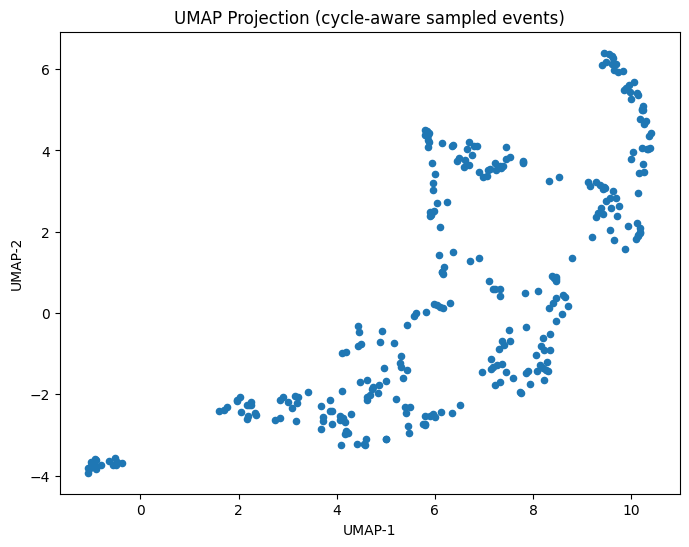


Cluster counts (events):
cluster
-1    145
 2    130
 1     14
 0     11
Name: count, dtype: int64


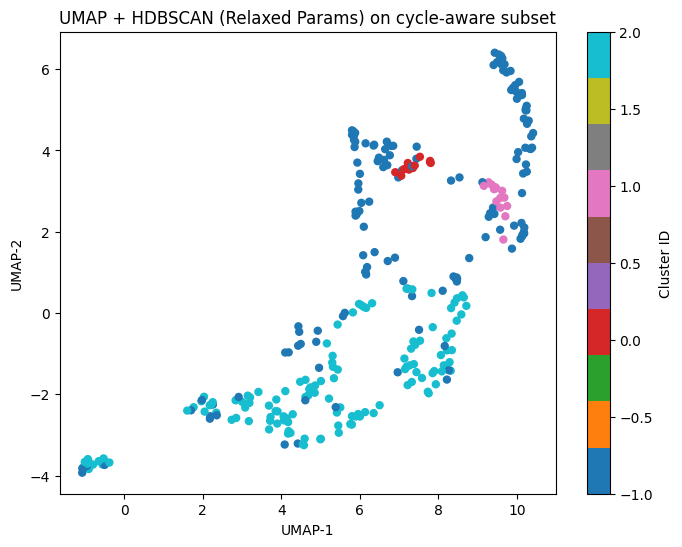


Cluster Feature Means (events, excluding noise):


,feat_centroid_mean,feat_flatness_mean,feat_roll95_amp_mean,feat_duration_s,feat_tkeo_mean,feat_flux_mean
cluster,,,,,,
0,358.020673,0.111068,1182.024436,0.203636,7.037192e-08,0.000343
1,292.038265,0.100172,1112.643485,0.152857,1.206431e-07,0.000436
2,460.397925,0.197646,2077.251029,0.153154,6.769884e-08,0.000239



Cluster Counts (events, excluding noise):
cluster
2    130
1     14
0     11
Name: count, dtype: int64

Unique cycles per cluster (excluding noise):


,cluster,n_cycles
0,2,16
1,1,10
2,0,7



Cycle → majority cluster mapping (excluding noise):


,global_cycle_id,majority_cluster,n_events
1,10_0,2,17
3,10_1,2,10
5,11_0,2,11
7,2_0,2,4
10,2_1,2,7
13,2_2,2,7
15,3_0,2,7
17,3_1,2,8
19,4_0,2,9
20,4_1,2,8


Total cycles mapped: 16


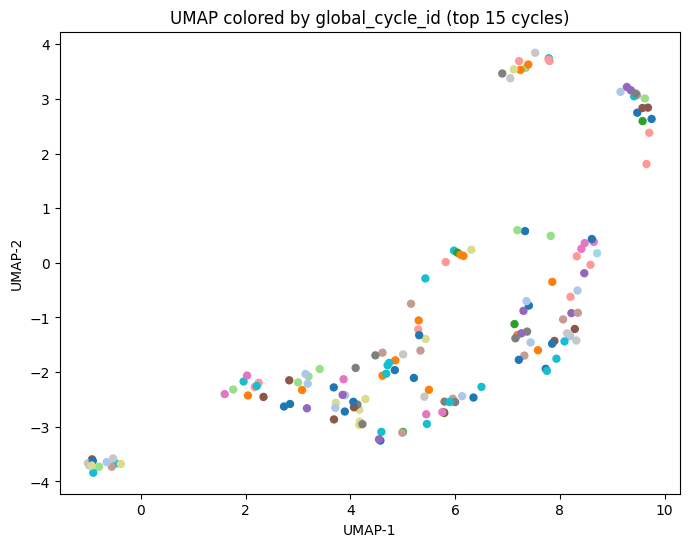

In [ ]:
# =========================
# STEP 3A: UMAP projection (cycle-aware subset)
# STEP 3B: HDBSCAN clustering
# PLUS: cycle-level diagnostics
# =========================

import umap
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import hdbscan
import pandas as pd

# -------------------------
# Standardize features before UMAP / clustering
# -------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# -------------------------
# STEP 3A: UMAP
# -------------------------
umap_model = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    random_state=42
)

X_umap = umap_model.fit_transform(X_scaled)
print("UMAP shape:", X_umap.shape)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], s=20)
plt.title("UMAP Projection (cycle-aware sampled events)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

# -------------------------
# STEP 3B: HDBSCAN clustering
# -------------------------
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5
)

labels = clusterer.fit_predict(X_scaled)

# Attach embeddings + labels back to df_features
df_features = df_features.copy()
df_features["cluster"] = labels
df_features["umap1"] = X_umap[:, 0]
df_features["umap2"] = X_umap[:, 1]

print("\nCluster counts (events):")
print(df_features["cluster"].value_counts())

# Plot clusters
plt.figure(figsize=(8, 6))
scatter = plt.scatter(df_features["umap1"], df_features["umap2"],
                      c=df_features["cluster"], cmap="tab10", s=25)
plt.colorbar(scatter, label="Cluster ID")
plt.title("UMAP + HDBSCAN (Relaxed Params) on cycle-aware subset")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

# -------------------------
# Cluster feature means (ignore noise)
# -------------------------
df_clustered = df_features[df_features["cluster"] != -1].copy()

cluster_summary = df_clustered.groupby("cluster")[FEATURE_COLS].mean()
print("\nCluster Feature Means (events, excluding noise):")
display(cluster_summary)

print("\nCluster Counts (events, excluding noise):")
print(df_clustered["cluster"].value_counts())

# =========================
# ✅ Cycle-based extras (THIS is the important conversion part)
# =========================

# 1) How many UNIQUE cycles appear in each cluster?
cycles_per_cluster = (
    df_clustered.groupby("cluster")["global_cycle_id"]
               .nunique()
               .sort_values(ascending=False)
               .rename("n_cycles")
               .reset_index()
)

print("\nUnique cycles per cluster (excluding noise):")
display(cycles_per_cluster)

# 2) For each cycle, what cluster does it mostly belong to? (majority vote)
cycle_majority = (
    df_clustered.groupby(["global_cycle_id", "cluster"])
                .size()
                .reset_index(name="n_events")
                .sort_values(["global_cycle_id", "n_events"], ascending=[True, False])
)

cycle_majority = cycle_majority.groupby("global_cycle_id").head(1)  # pick top cluster per cycle
cycle_majority = cycle_majority.rename(columns={"cluster": "majority_cluster"})

print("\nCycle → majority cluster mapping (excluding noise):")
display(cycle_majority.head(10))

print("Total cycles mapped:", cycle_majority["global_cycle_id"].nunique())

# 3) Optional visualization: UMAP colored by cycle id (can be busy if many cycles)
#    We'll show only top 15 cycles by event count for readability.
top_cycles = (
    df_clustered["global_cycle_id"].value_counts().head(15).index.tolist()
)

df_top = df_clustered[df_clustered["global_cycle_id"].isin(top_cycles)].copy()

plt.figure(figsize=(8, 6))
scatter2 = plt.scatter(df_top["umap1"], df_top["umap2"],
                       c=pd.Categorical(df_top["global_cycle_id"]).codes,
                       s=25, cmap="tab20")
plt.title("UMAP colored by global_cycle_id (top 15 cycles)")
plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.show()

Events in last 6h: 2871
Cycles in last 6h: 10

Event counts per time_bin:
time_bin
0-60       1089
60-120      714
120-240     680
240-360     388
Name: count, dtype: int64

Cycle-based bin summary (per-cycle means):


,global_cycle_id,session_id,time_bin,feat_centroid_mean,feat_flatness_mean,feat_roll95_amp_mean,feat_duration_s,feat_tkeo_mean,feat_flux_mean
0,10_0,10,0-60,371.659376,0.141864,1570.800305,0.169474,6.190001e-06,0.001252
1,10_0,10,60-120,406.436043,0.162936,1791.611811,0.179318,1.601762e-05,0.001299
2,10_0,10,120-240,374.166798,0.145217,1633.937220,0.193466,1.085635e-06,0.000696
3,10_0,10,240-360,411.662098,0.171110,1828.710342,0.173291,1.320112e-07,0.000341
4,11_0,11,0-60,395.183654,0.145437,1557.412985,0.179130,3.633945e-06,0.000777
5,11_0,11,60-120,429.313947,0.144459,1561.120136,0.184348,1.616258e-07,0.000341
6,11_0,11,120-240,422.109674,0.153307,1702.619989,0.201744,9.152607e-07,0.000554
7,11_0,11,240-360,393.735193,0.144029,1674.064314,0.168395,6.518059e-06,0.001264
8,2_0,2,0-60,371.309162,0.140628,1609.731693,0.197513,7.378712e-06,0.001156
9,2_1,2,0-60,364.694039,0.142760,1549.428161,0.198438,1.710645e-06,0.000759


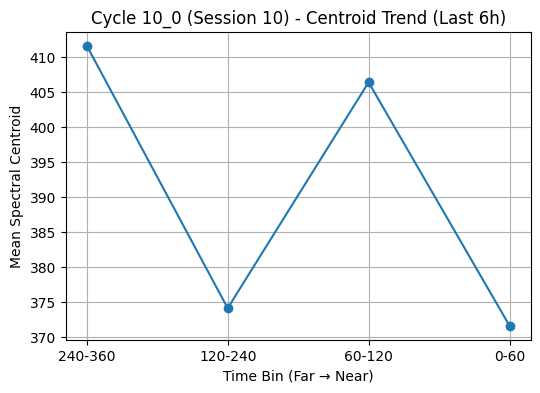

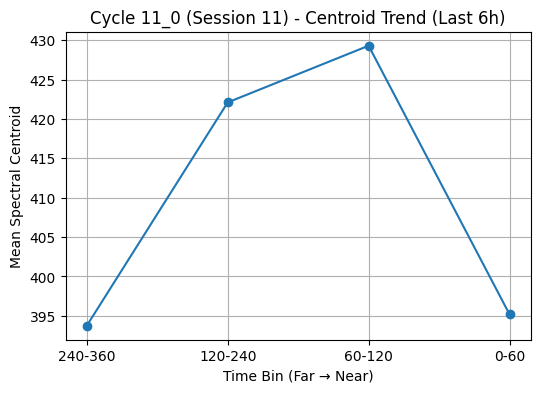

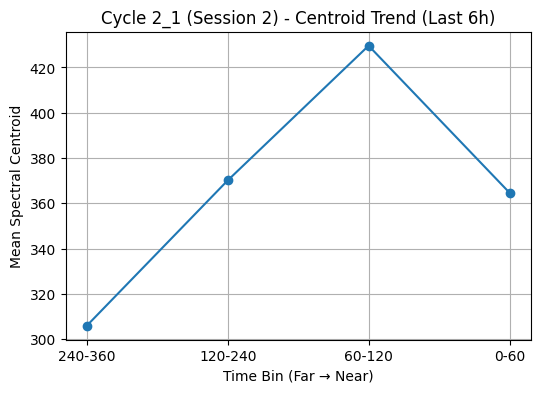

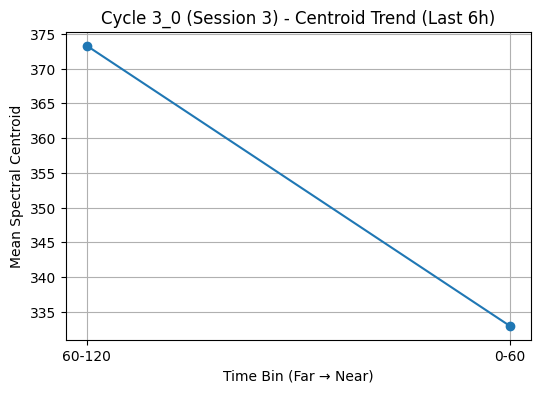

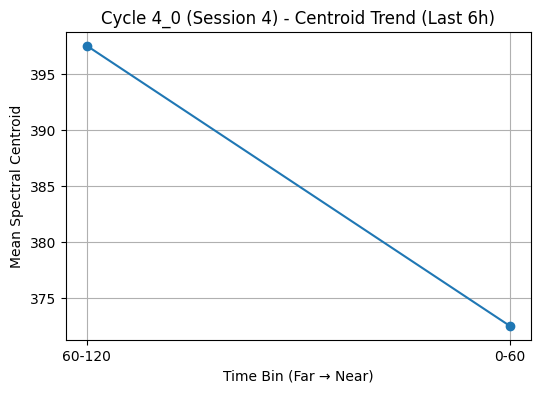

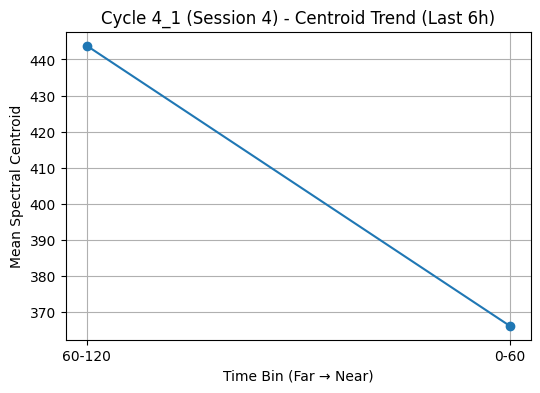

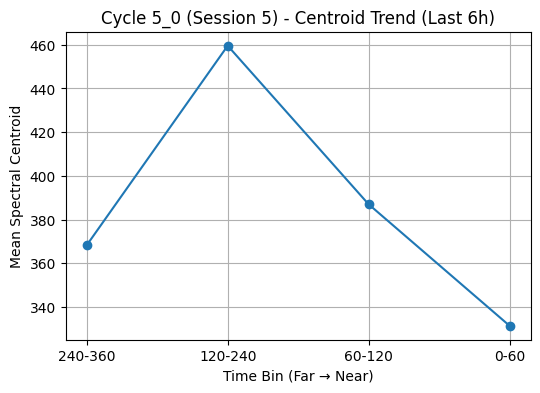

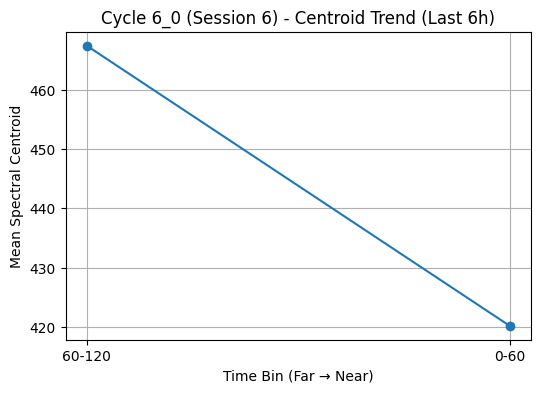

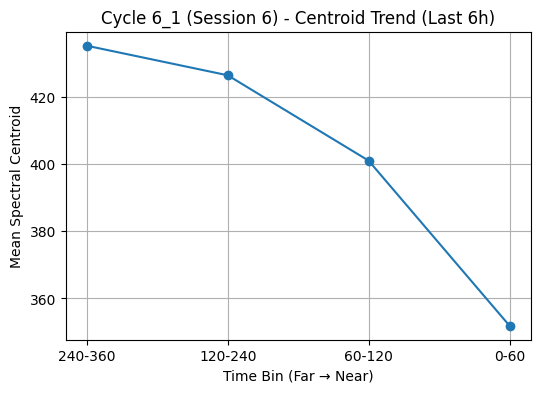


Cycles in 2h window: 10
Sessions in 2h window: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(10), np.int64(11)]

Cycle 10_0 (Session 10)
time_bin
120-60    132
60-0       57
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



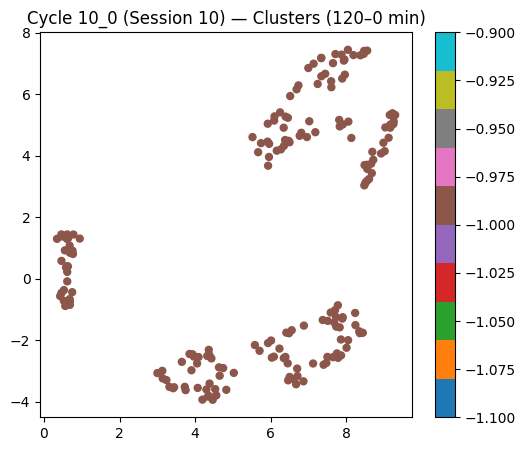

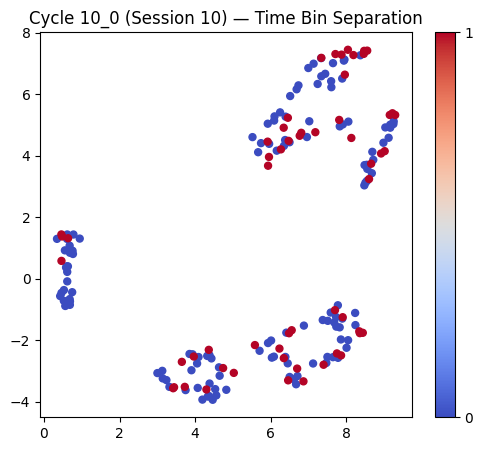


Cycle 11_0 (Session 11)
time_bin
60-0      46
120-60    23
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



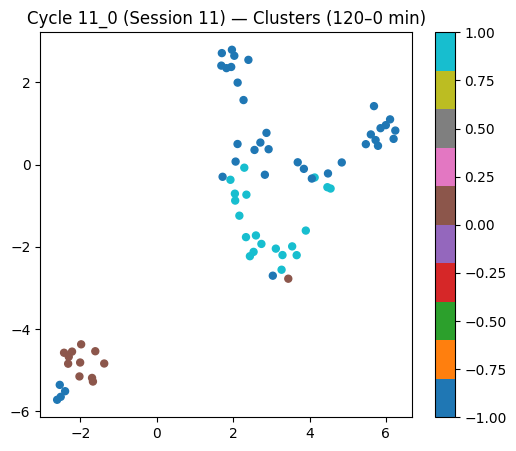

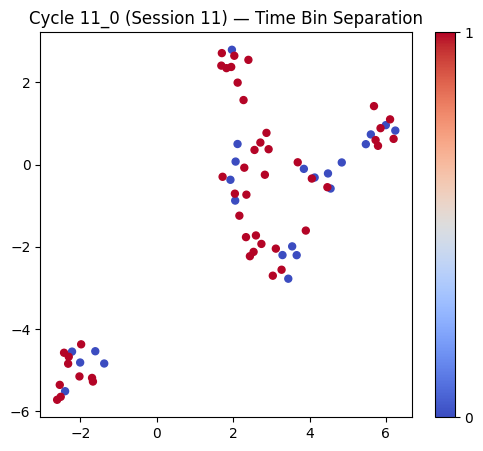


Cycle 2_1 (Session 2)
time_bin
60-0      96
120-60    53
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



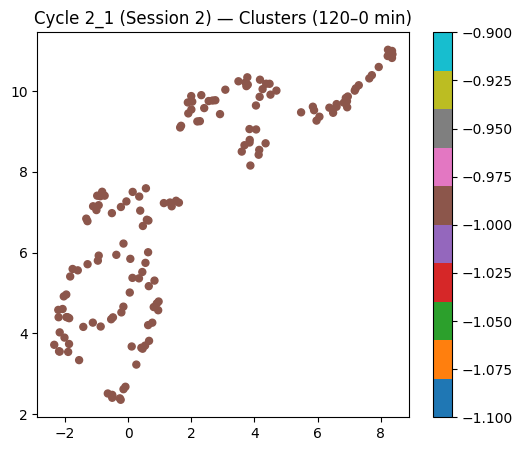

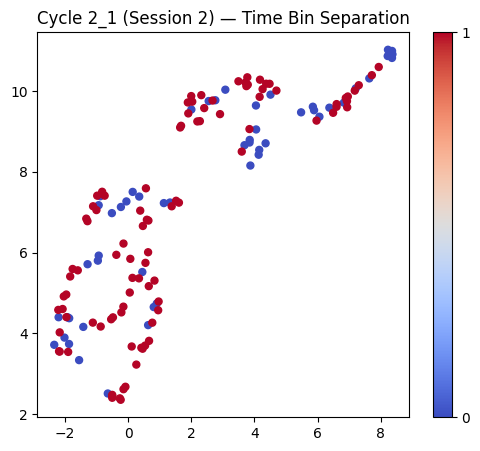


Cycle 3_0 (Session 3)
time_bin
120-60    135
60-0       56
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



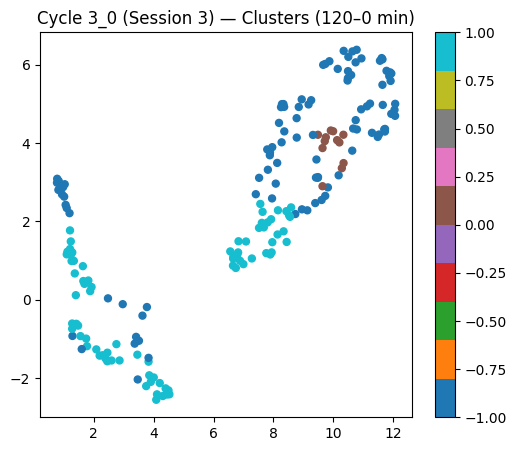

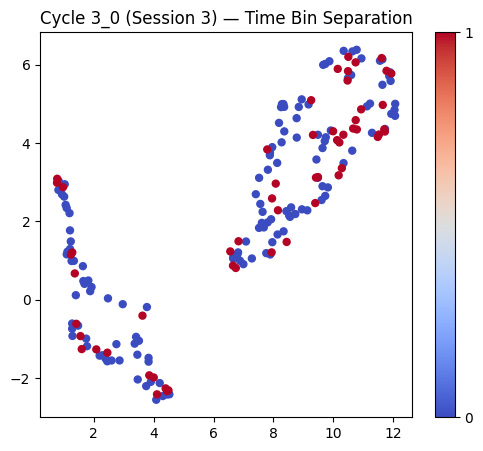


Cycle 4_0 (Session 4)
time_bin
60-0      130
120-60    117
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



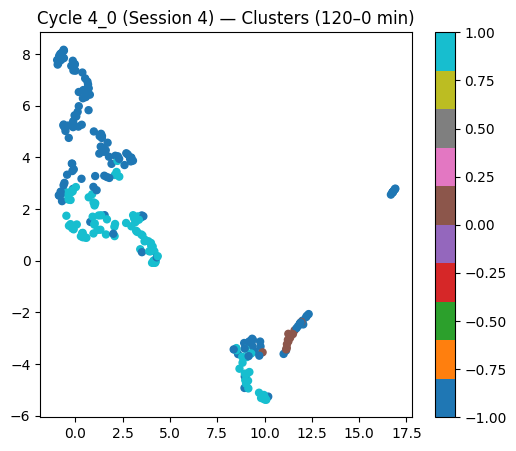

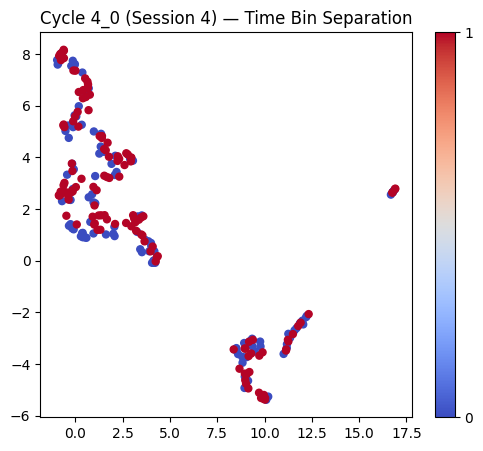


Cycle 4_1 (Session 4)
time_bin
60-0      90
120-60    55
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



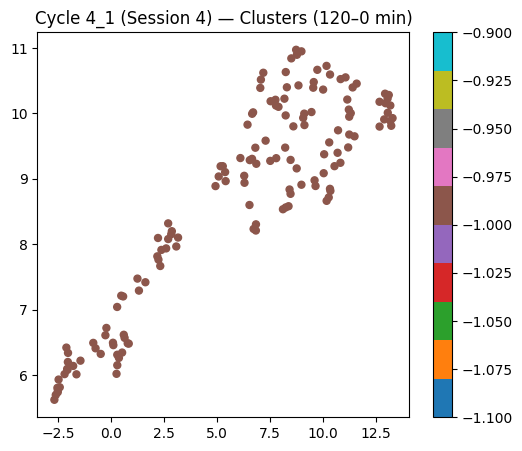

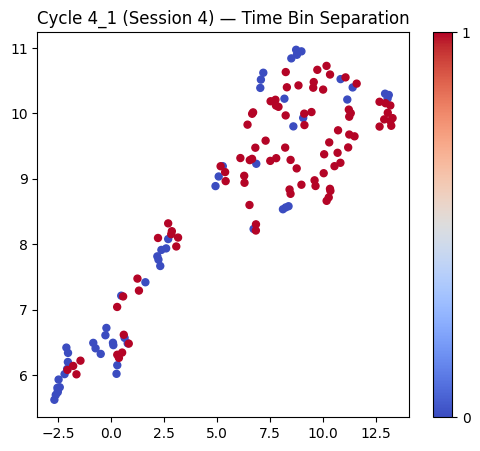


Cycle 5_0 (Session 5)
time_bin
60-0      21
120-60    18
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



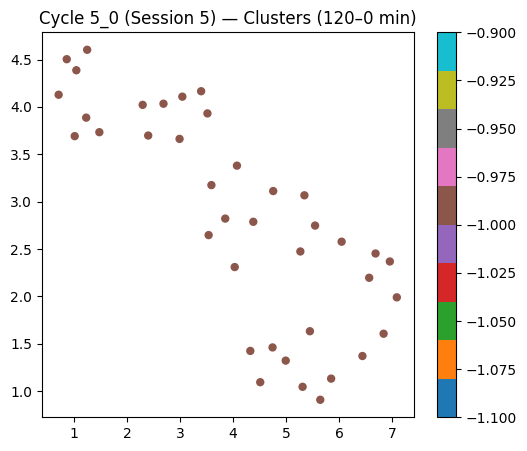

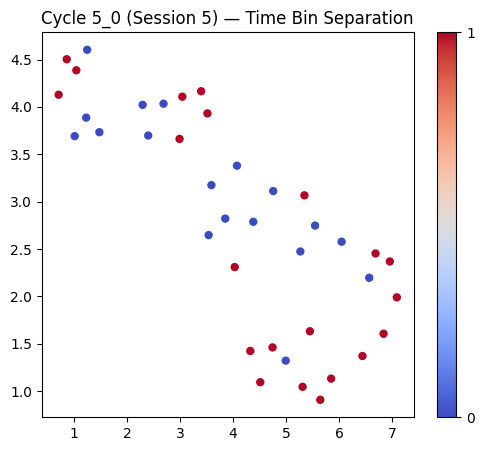


Cycle 6_0 (Session 6)
time_bin
60-0      235
120-60    108
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



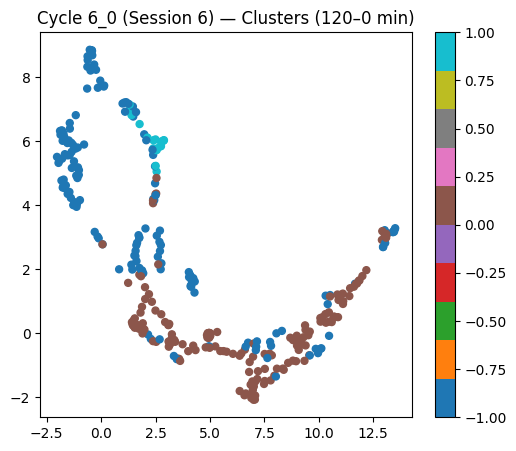

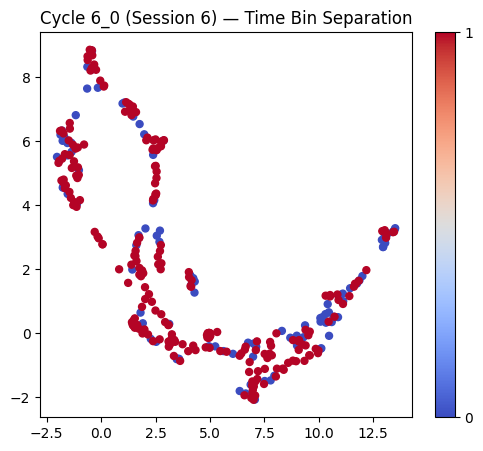


Cycle 6_1 (Session 6)
time_bin
60-0      169
120-60     73
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



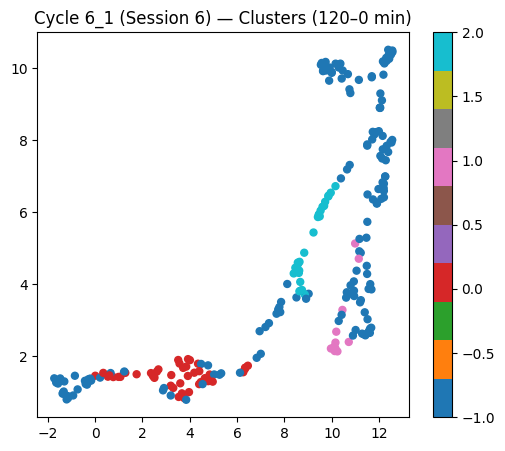

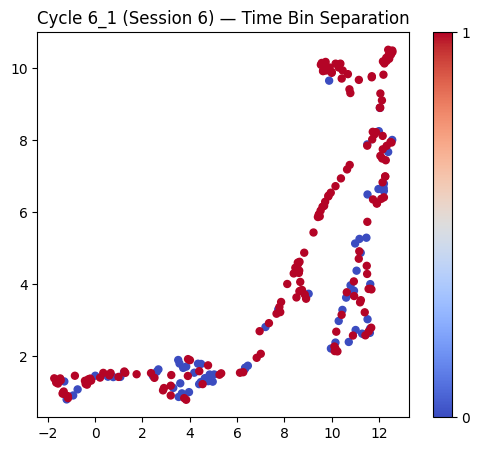

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import umap
import hdbscan
from sklearn.preprocessing import StandardScaler

# =========================
# CYCLE-BASED: Focus on last 6 hours
# =========================

df_6h = df_pool[df_pool["minutes_until_defecation"] <= 360].copy()

assert "global_cycle_id" in df_6h.columns, "global_cycle_id missing in df_pool!"
print("Events in last 6h:", len(df_6h))
print("Cycles in last 6h:", df_6h["global_cycle_id"].nunique())

# -------------------------
# 6h bins (near vs far)
# -------------------------
bins_6h = [0, 60, 120, 240, 360]
labels_6h = ["0-60", "60-120", "120-240", "240-360"]

df_6h["time_bin"] = pd.cut(
    df_6h["minutes_until_defecation"],
    bins=bins_6h,
    labels=labels_6h,
    include_lowest=True
)

print("\nEvent counts per time_bin:")
print(df_6h["time_bin"].value_counts())

FEATURE_COLS = [
    "feat_centroid_mean",
    "feat_flatness_mean",
    "feat_roll95_amp_mean",
    "feat_duration_s",
    "feat_tkeo_mean",
    "feat_flux_mean",
]

# =========================
# Cycle-based bin summary (per-cycle means inside each bin)
# =========================
bin_summary_cycle = (
    df_6h
    .groupby(["global_cycle_id", "session_id", "time_bin"], observed=True)[FEATURE_COLS]
    .mean()
    .reset_index()
)

print("\nCycle-based bin summary (per-cycle means):")
display(bin_summary_cycle.head(10))

# =========================
# Plot centroid trend per CYCLE (not session)
# =========================
ordered_bins = ["240-360", "120-240", "60-120", "0-60"]  # far → near (same bins, reversed)

for cid in sorted(df_6h["global_cycle_id"].unique()):
    g = df_6h[df_6h["global_cycle_id"] == cid]

    # per-bin mean (within this cycle)
    means = g.groupby("time_bin", observed=True)["feat_centroid_mean"].mean()
    means = means.reindex(ordered_bins)

    # skip tiny cycles
    if means.count() < 2:
        continue

    sid = g["session_id"].iloc[0] if "session_id" in g.columns and len(g) else "?"
    plt.figure(figsize=(6,4))
    plt.plot(ordered_bins, means.values, marker="o")
    plt.title(f"Cycle {cid} (Session {sid}) - Centroid Trend (Last 6h)")
    plt.ylabel("Mean Spectral Centroid")
    plt.xlabel("Time Bin (Far → Near)")
    plt.grid(True)
    plt.show()

# ============================================================
# CYCLE-BASED last 2h: focus only 120–60 and 60–0
# ============================================================

df_2h = df_pool[df_pool["minutes_until_defecation"] <= 120].copy()
assert "global_cycle_id" in df_2h.columns, "global_cycle_id missing in df_pool!"

bins_2h = [0, 60, 120]
labels_2h = ["60-0", "120-60"]

df_2h["time_bin"] = pd.cut(
    df_2h["minutes_until_defecation"],
    bins=bins_2h,
    labels=labels_2h,
    include_lowest=True
)

print("\nCycles in 2h window:", df_2h["global_cycle_id"].nunique())
print("Sessions in 2h window:", sorted(df_2h["session_id"].unique()) if "session_id" in df_2h.columns else "NA")

# =========================
# Per-CYCLE clustering & visualization (instead of per-session)
# =========================
for cid in sorted(df_2h["global_cycle_id"].unique()):

    g = df_2h[df_2h["global_cycle_id"] == cid].copy()

    # Need both bins present inside this cycle
    if g["time_bin"].nunique() < 2:
        continue

    sid = g["session_id"].iloc[0] if "session_id" in g.columns and len(g) else "?"
    print(f"\nCycle {cid} (Session {sid})")
    print(g["time_bin"].value_counts())

    # Prepare features
    g = g.dropna(subset=FEATURE_COLS)
    if len(g) < 20:  # avoid unstable clustering on tiny samples
        print("  Skipping: too few events after NaN removal:", len(g))
        continue

    X = g[FEATURE_COLS].values
    Xs = StandardScaler().fit_transform(X)

    # UMAP
    reducer = umap.UMAP(n_neighbors=10, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(Xs)

    # HDBSCAN
    clusterer = hdbscan.HDBSCAN(min_cluster_size=10, min_samples=5)
    labels_cluster = clusterer.fit_predict(Xs)

    # Plot clustering
    plt.figure(figsize=(6,5))
    scatter = plt.scatter(
        X_umap[:,0],
        X_umap[:,1],
        c=labels_cluster,
        cmap="tab10",
        s=25
    )
    plt.title(f"Cycle {cid} (Session {sid}) — Clusters (120–0 min)")
    plt.colorbar(scatter)
    plt.show()

    # Plot time-bin coloring
    plt.figure(figsize=(6,5))
    scatter = plt.scatter(
        X_umap[:,0],
        X_umap[:,1],
        c=g["time_bin"].map({"120-60":0, "60-0":1}),
        cmap="coolwarm",
        s=25
    )
    plt.title(f"Cycle {cid} (Session {sid}) — Time Bin Separation")
    plt.colorbar(scatter, ticks=[0,1])
    plt.show()